# Exploratory Data Analysis & Visualization

**Graphical and statistical
summaries to uncover insights**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("books_cleaned.csv")

df.head()

,title,price,rating,availability,url,price_clean,rating_numeric,price_category,rating_category
0,A Light in the Attic,Â£51.77,Three,in stock,a-light-in-the-attic_1000/index.html,51.77,3,High,Average
1,Tipping the Velvet,Â£53.74,One,in stock,tipping-the-velvet_999/index.html,53.74,1,High,Low Rated
2,Soumission,Â£50.10,One,in stock,soumission_998/index.html,50.10,1,High,Low Rated
3,Sharp Objects,Â£47.82,Four,in stock,sharp-objects_997/index.html,47.82,4,High,Highly Rated
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,in stock,sapiens-a-brief-history-of-humankind_996/index...,54.23,5,High,Highly Rated


In [4]:
print(df.shape)

(1000, 9)


In [3]:
df.describe()

,price_clean,rating_numeric
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


In [5]:
print("Average Price:", df["price_clean"].mean())
print("Median Price:", df["price_clean"].median())
print("Minimum Price:", df["price_clean"].min())
print("Maximum Price:", df["price_clean"].max())

Average Price: 35.07035
Median Price: 35.980000000000004
Minimum Price: 10.0
Maximum Price: 59.99


In [6]:
rating_counts = df["rating_numeric"].value_counts().sort_index()

print(rating_counts)

rating_numeric
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


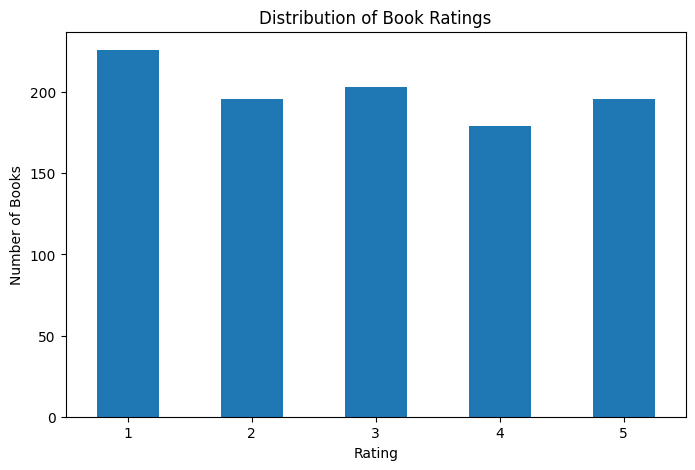

In [7]:
plt.figure(figsize=(8,5))

rating_counts.plot(kind="bar")

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)

plt.show()

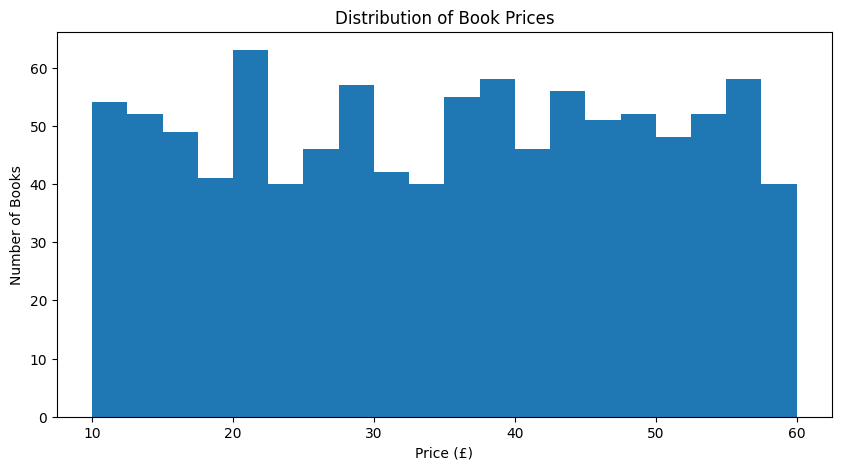

In [8]:
plt.figure(figsize=(10,5))

plt.hist(df["price_clean"], bins=20)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

In [9]:
price_counts = df["price_category"].value_counts()

print(price_counts)

price_category
High      403
Medium    401
Low       196
Name: count, dtype: int64


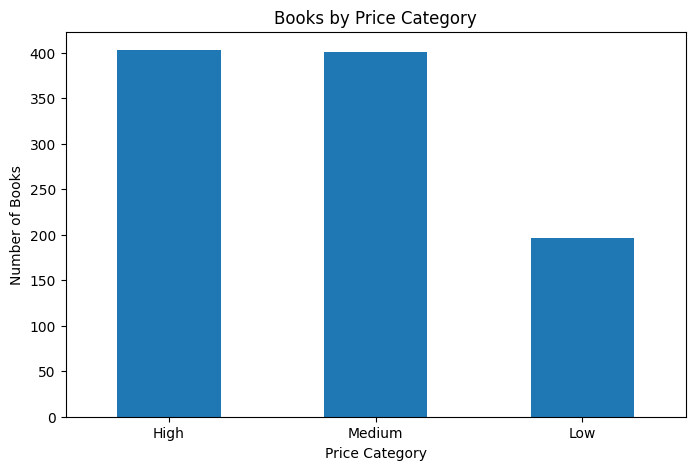

In [10]:
plt.figure(figsize=(8,5))

price_counts.plot(kind="bar")

plt.title("Books by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)

plt.show()

In [11]:
rating_category_counts = df["rating_category"].value_counts()

print(rating_category_counts)

rating_category
Low Rated       422
Highly Rated    375
Average         203
Name: count, dtype: int64


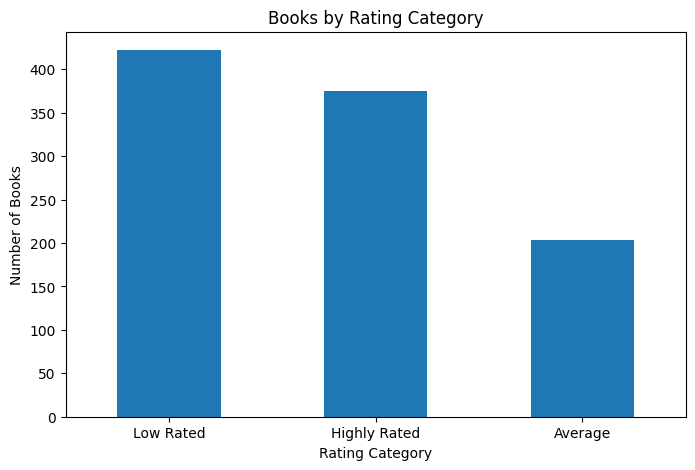

In [12]:
plt.figure(figsize=(8,5))

rating_category_counts.plot(kind="bar")

plt.title("Books by Rating Category")
plt.xlabel("Rating Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)

plt.show()

In [13]:
cheapest_books = df.sort_values(
    by="price_clean"
).head(10)

cheapest_books[["title", "price_clean", "rating_numeric"]]

,title,price_clean,rating_numeric
638,An Abundance of Katherines,10.00,5
501,The Origin of Species,10.01,4
716,The Tipping Point: How Little Things Can Make ...,10.02,2
84,Patience,10.16,3
302,Greek Mythic History,10.23,5
558,The Fellowship of the Ring (The Lord of the Ri...,10.27,2
479,History of Beauty,10.29,4
242,The Lucifer Effect: Understanding How Good Peo...,10.40,1
434,"NaNo What Now? Finding your editing process, r...",10.41,4
274,Pet Sematary,10.56,3


In [14]:
expensive_books = df.sort_values(
    by="price_clean",
    ascending=False
).head(10)

expensive_books[["title", "price_clean", "rating_numeric"]]

,title,price_clean,rating_numeric
648,The Perfect Play (Play by Play #1),59.99,3
617,Last One Home (New Beginnings #1),59.98,3
860,Civilization and Its Discontents,59.95,2
560,The Barefoot Contessa Cookbook,59.92,5
366,The Diary of a Young Girl,59.90,3
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1
387,Boar Island (Anna Pigeon #19),59.48,3
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4
393,The Improbability of Love,59.45,1


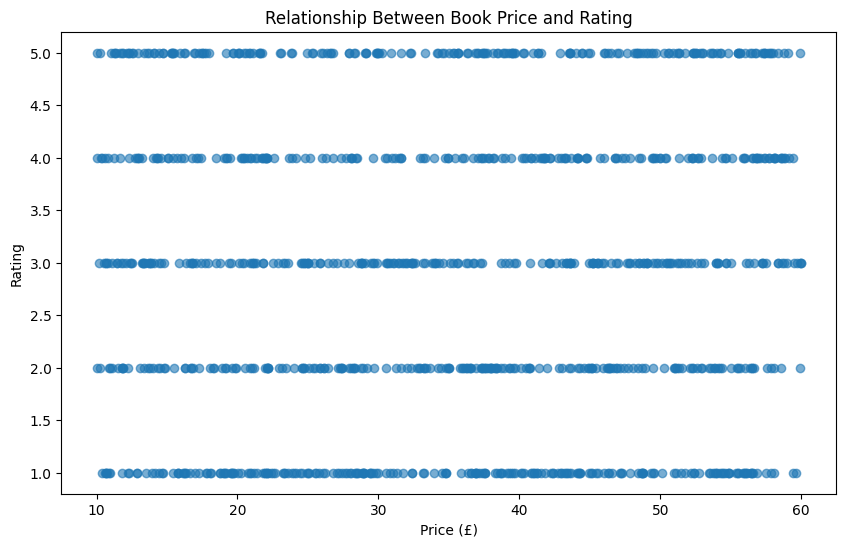

In [15]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["price_clean"],
    df["rating_numeric"],
    alpha=0.6
)

plt.title("Relationship Between Book Price and Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.show()

In [16]:
correlation = df["price_clean"].corr(
    df["rating_numeric"]
)

print("Price-Rating Correlation:", correlation)

Price-Rating Correlation: 0.028166239485872935


In [17]:
avg_price_rating = df.groupby(
    "rating_numeric"
)["price_clean"].mean()

print(avg_price_rating)

rating_numeric
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price_clean, dtype: float64


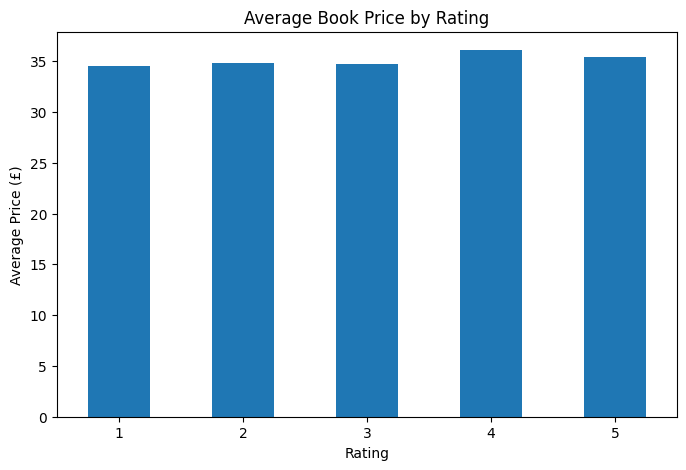

In [18]:
plt.figure(figsize=(8,5))

avg_price_rating.plot(kind="bar")

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=0)

plt.show()

In [19]:
rating_counts = (
    df.groupby("rating_numeric")
      .size()
      .reset_index(name="book_count")
)

rating_counts

,rating_numeric,book_count
0,1,226
1,2,196
2,3,203
3,4,179
4,5,196


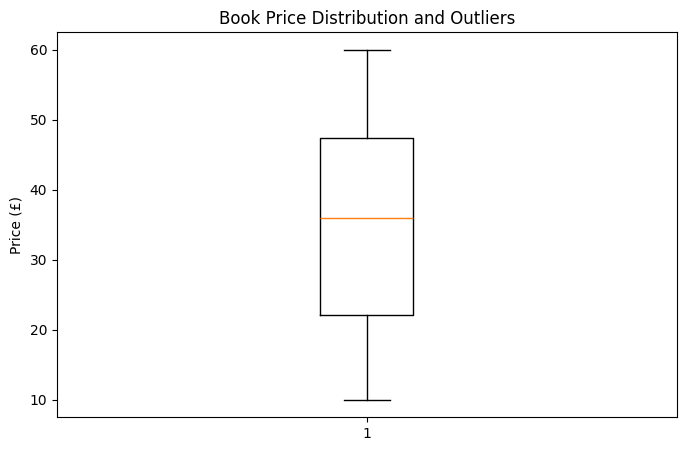

In [20]:
plt.figure(figsize=(8,5))

plt.boxplot(df["price_clean"])

plt.title("Book Price Distribution and Outliers")
plt.ylabel("Price (£)")

plt.show()

In [21]:
correlation_matrix = df[
    ["price_clean", "rating_numeric"]
].corr()

print(correlation_matrix)

                price_clean  rating_numeric
price_clean        1.000000        0.028166
rating_numeric     0.028166        1.000000


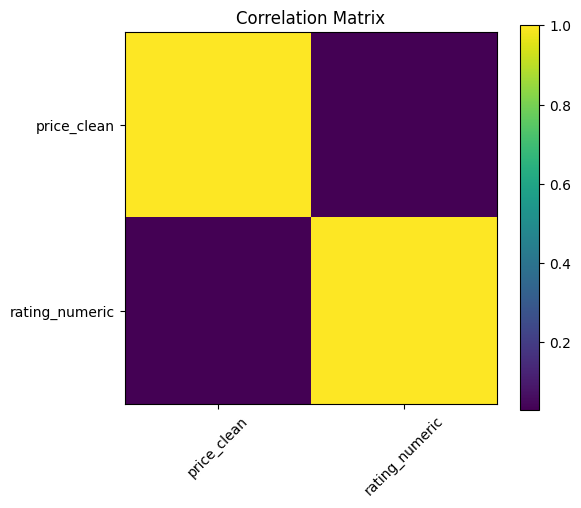

In [22]:
plt.figure(figsize=(6,5))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

In [23]:
print("Total Books:", len(df))
print("Average Price:", round(df["price_clean"].mean(), 2))
print("Median Price:", round(df["price_clean"].median(), 2))
print("Average Rating:", round(df["rating_numeric"].mean(), 2))
print("Most Common Rating:", df["rating_numeric"].mode()[0])
print("Most Common Price Category:", df["price_category"].mode()[0])
print("Price-Rating Correlation:", round(correlation, 3))

Total Books: 1000
Average Price: 35.07
Median Price: 35.98
Average Rating: 2.92
Most Common Rating: 1
Most Common Price Category: High
Price-Rating Correlation: 0.028
